In [13]:
import numpy as np
import pandas as pd
import scanpy as sc
from datetime import datetime
import os
from matplotlib import pyplot as plt
%matplotlib inline

In [14]:
os.chdir('/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021')

# 0: config (later we will outsource this part to yaml, for now we will continue setting all variables here)
sc._settings.ScanpyConfig.n_jobs = 6

# 1: Variables for Data loading and set-up
#sample               = '4d0dea92-e759-4a1c-b574-934104ecb0d1'
working_dir          = '/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell/'
result_folder        = working_dir+'samples_merged/'
result_file_name     = 'samples_merged'#.h5ad'
count_file_format    = 'hd5'              # either 'hd5' or mtx file
count_file_cache     = True
cell_annotation_file = '/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/Wang2021_marker_genes_flat.tsv'
cellcycle_genes_file = '/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/cell_cycle_markers_regev_lab.txt'
var_names            = 'gene_symbols'     # either gene symbols or gene_ids
unique_var_names     = True  # if variable names are not unique, make them unique (can lead to probelms if marker genes are affected)
remove_existing_log  = True  # if True start a new log file and remove the old. If false, log file will be expanded

# 2: Quality control and Diagnostics
plot_high_expression_gene_nr = 20            # Number of highly expressed genes to be plotted
filter_min_genes             = 200           # Minimum number of genes that need to be expressed in a cell                  possible debris with too few genes expressed (< 200)
filter_max_genes             = 10000         # Maximum number of genes that need to be expressed in a cell                  possible more than one cell with too many genes expressed (> 10,000
filter_min_counts_per_cell   = 1000          # Filter out cells that have a to few counts per cell                         too few total transcript counts (< 300); or UMIs
filter_min_cells             = 3             # Minimum number of cells that need to contain a gene
filter_n_genes_by_counts     = 10000         # Filter out cells that have a higher total gene count                          
filter_pct_counts_mt         = 10            # Filter out cells with a higher percentage of mitochondrial genes             mitochondrial gene expression over the total transcript counts (> 10%)
filter_total_counts          = 10000         # Filter out cells that have a higher total count per cell                     and too many UMIs (> 10,000)

# 3: Normalize and scale
perform_scaling           = True             # If True, scale the data matrix
scaling_target_sum        = 1e4              # Sum to which each cells library size is scaled
perform_log_normalization = True             # Apply natural base logarithm to the data matrix

# 4: DE analysis and filtering
use_flavor_hvf_settings = True               # If true, use DE analysis and filtering settings to that of a specific protocol (e.g. Seurat)
hvf_flavor = 'seurat'                        # Set the protocol (flavor) to use, e.g. seurat to reproduce seurat results 
hvf_n_top_genes = 3000                       # Filter out genes that are not the n top variable genes

hvf_perform_regression_total_counts  = True  # Regress out effects caused by the total amount of counts
hvf_perform_regression_pct_counts_mt = True  # Regress out effects caused by the percenatage of mitochondrial genes
hvf_perform_regression_cell_cycle    = False  # Regress out effects caused by cell cylce state of cells
hvf_visulalize_cell_cycle            = False

# 5: PCA clustering, NNG, embedding
ngg_n_neighbours                        = 20     # seurat uses 20
n_pcs                                   = 30
select_components_by_explained_variance = False
explained_variance_threshold            = 0.1    # Carefull: Value depends strongly on number dimensions

## if use_flavor_hvf_settings == False, these settings will be used:
var_genes_min_mean      = 0.0123
var_genes_max_mean      = 3
var_genes_min_disp      = 0.5
var_genes_max_value     = 10

In [15]:
# 1: Data loading and set-up

## change settings in the sc module for verbosity, logging and figures
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

## make missing folders
os.makedirs(working_dir, exist_ok=True)
os.makedirs(result_folder, exist_ok=True)
os.makedirs(result_folder+'/hd5', exist_ok=True)
os.makedirs(result_folder+'/QC', exist_ok=True)

# create a log file
if remove_existing_log == True:
    if os.path.exists(result_folder+'/log.txt'):
        os.remove(result_folder+'/log.txt')

logfile = open(result_folder+'/log.txt', 'w')
logfile.write(str(datetime.now())+' The scanpy pipeline log file was initialized' +  '\n')
        
## change to working directory
os.chdir(working_dir)
results_file = result_file_name  # the file that will store the analysis results
logfile.write(str(datetime.now())+' Set working directory to: ' + working_dir + '\n')

122

In [16]:
import os
import scanpy as sc

# Set the path to your data folder
data_folder = '/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell/'

# Create a list to store all AnnData objects
adata_list = []
sample_names = []

# Iterate through sample subfolders
for sample_dir in sorted(os.listdir(data_folder)):
    sample_path = os.path.join(data_folder, sample_dir)
    
    # Check if it's a directory
    if os.path.isdir(sample_path):
        # Look for the filtered h5ad file
        filtered_file = os.path.join(sample_path, f"{sample_dir}_filtered.h5ad")
        
        if os.path.exists(filtered_file):
            # Load individual h5ad file
            adata_sample = sc.read(filtered_file)
            print(f'Read sc data for sample: {sample_dir} from {filtered_file}')
            
            # Store the sample
            adata_list.append(adata_sample)
            sample_names.append(sample_dir)

# Concatenate all samples at once
if len(adata_list) > 0:
    adata = sc.concat(adata_list, label='sample_id', keys=sample_names, join='outer')
    print(f'\nTotal samples merged: {len(sample_names)}')
    print(f'Sample names: {sample_names}')
else:
    raise ValueError("No samples found to merge!")

# Optionally, you can perform additional steps or checks on the combined_adata

# Save the combined AnnData object if needed
#combined_adata.write('/path/to/save/combined_data.h5ad')
logfile.write(str(datetime.now())+ ' Inital adata object contains ' + str(adata.n_obs) + ' cells and ' + str(adata.n_vars)+ ' feaatures\n')
logfile.flush()


Read sc data for sample: C3L-03405 from /home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell/C3L-03405/C3L-03405_filtered.h5ad
Read sc data for sample: C3L-03968 from /home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell/C3L-03968/C3L-03968_filtered.h5ad
Read sc data for sample: C3N-01334 from /home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell/C3N-01334/C3N-01334_filtered.h5ad
Read sc data for sample: C3N-02190 from /home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell/C3N-02190/C3N-02190_filtered.h5ad
Read sc data for sample: C3N-02784 from /home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell/C3N-02784/C3N-02784_filtered.h5ad
Read sc data for sample: C3N-03188 from /home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell/C3N-03188/C3N-03188_filtered.h5ad

Total samples merged: 6
Sample names: ['C3L-03405', 'C3L-03968', 'C3N-01334', 'C3N-02190', 'C3N-02784', 'C3N-03188']


/home/borisvdm/Software/miniconda3/envs/single-cell/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [17]:
adata

AnnData object with n_obs × n_vars = 45245 × 41076
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'total_counts_mt', 'pct_counts_mt', 'sample_id'

In [ ]:
# 2: Quality control and Diagnostics

## Make a first basic diagnostic screen
print('Number cells:', adata.n_obs)
print('Number features:', adata.n_vars)
print('Non-zero counts:',adata.X.count_nonzero())
print('Zero counts:',(adata.n_obs*adata.n_vars)-adata.X.count_nonzero())
print('% Non-Zero:',adata.X.count_nonzero()/(adata.n_obs*adata.n_vars)*100)

# calculate general qc values
sc.pp.calculate_qc_metrics(adata, expr_type='counts', var_type = 'genes', inplace=True)

# print diagnostic variables
print('Minimum number cells per gene:', min(adata.var['n_cells_by_counts']))
print('Maximum number cells per gene:', max(adata.var['n_cells_by_counts']))
print('Mean number cells per gene:', np.mean(adata.var['n_cells_by_counts']))
print('Median number cells per gene:', np.median(adata.var['n_cells_by_counts']))
print('Minimum number counts per gene:', min(adata.var['total_counts']))
print('Maximum number counts per gene:', max(adata.var['total_counts']))
print('Mean number counts per gene:', np.mean(adata.var['total_counts']))
print('Median number counts per gene:', np.median(adata.var['total_counts']))

print('Minimum number genes per cell:', min(adata.obs['n_genes_by_counts']))
print('Maximum number genes per cell:', max(adata.obs['n_genes_by_counts']))
print('Mean number genes per cell:', np.mean(adata.obs['n_genes_by_counts']))
print('Median number genes per cell:', np.median(adata.obs['n_genes_by_counts']))
print('Minimum number counts per cell:', min(adata.obs['total_counts']))
print('Maximum number counts per cell:', max(adata.obs['total_counts']))
print('Mean number counts per cell:', np.mean(adata.obs['total_counts']))
print('Median number counts per cell:', np.median(adata.obs['total_counts']))

print('Cells with less than 200 genes', len(adata.var['total_counts'][adata.var['total_counts'] < 200]))
print('Genes expressed in at least 3 cells', len(adata.obs['total_counts'][adata.obs['total_counts'] < 3]))

# Save diagnostic variables to log file
logfile.write(' Number cells: '   + str(adata.n_obs)+'\n')
logfile.write(' Number features: '+ str(adata.n_vars)+'\n')
logfile.write(' Non-zero counts: '+ str(adata.X.count_nonzero())+'\n')
logfile.write(' Zero counts: '    + str((adata.n_obs*adata.n_vars)-adata.X.count_nonzero())+'\n')
logfile.write(' % Non-Zero: '     + str(adata.X.count_nonzero()/(adata.n_obs*adata.n_vars)*100)+'\n')

logfile.write(str(datetime.now())+' Minimum number cells per gene: '+str(min(adata.var['n_cells_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Maximum number cells per gene: ' + str(max(adata.var['n_cells_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Mean number cells per gene: '    + str(np.mean(adata.var['n_cells_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Median number cells per gene: '  + str(np.median(adata.var['n_cells_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Minimum number counts per gene: '+ str(min(adata.var['total_counts']))+'\n')
logfile.write(str(datetime.now())+' Maximum number counts per gene: '+ str(max(adata.var['total_counts']))+'\n')
logfile.write(str(datetime.now())+' Mean number counts per gene: '   + str(np.mean(adata.var['total_counts']))+'\n')
logfile.write(str(datetime.now())+' Median number counts per gene: ' + str(np.median(adata.var['total_counts']))+'\n')

logfile.write(str(datetime.now())+' Minimum number genes per cell: ' + str(min(adata.obs['n_genes_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Maximum number genes per cell: ' + str(max(adata.obs['n_genes_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Mean number genes per cell: '    + str(np.mean(adata.obs['n_genes_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Median number genes per cell: '  + str(np.median(adata.obs['n_genes_by_counts']))+'\n')
logfile.write(str(datetime.now())+' Minimum number counts per cell: '+ str(min(adata.obs['total_counts']))+'\n')
logfile.write(str(datetime.now())+' Maximum number counts per cell: '+ str(max(adata.obs['total_counts']))+'\n')
logfile.write(str(datetime.now())+' Mean number counts per cell: '   + str(np.mean(adata.obs['total_counts']))+'\n')
logfile.write(str(datetime.now())+' Median number counts per cell: ' + str(np.median(adata.obs['total_counts']))+'\n')

logfile.write(str(datetime.now())+' Cells with less than 200 genes ' + str(len(adata.var['total_counts'][adata.var['total_counts'] < 200]))+'\n')
logfile.write(str(datetime.now())+' Genes expressed in at least 3 cells '   + str(len(adata.obs['total_counts'][adata.obs['total_counts'] > 3]))+'\n')
logfile.flush()

#adata.write(result_file_name+'_not_filtered.h5ad')

Number cells: 45245
Number features: 41076
Non-zero counts: 83184585
Zero counts: 1775299035
% Non-Zero: 4.475938561137278
Minimum number cells per gene: 0
Maximum number cells per gene: 45233
Mean number cells per gene: 2025.1384019865616
Median number cells per gene: 154.0
Minimum number counts per gene: 0.0
Maximum number counts per gene: 5380863.0
Mean number counts per gene: 3709.8657
Median number counts per gene: 164.0
Minimum number genes per cell: 396
Maximum number genes per cell: 5155
Mean number genes per cell: 1838.5365233727484
Median number genes per cell: 1572.0
Minimum number counts per cell: 1000.0
Maximum number counts per cell: 9999.0
Mean number counts per cell: 3368.0288
Median number counts per cell: 2421.0
Cells with less than 200 genes 21355
Genes expressed in at least 3 cells 0


normalizing counts per cell
    finished (0:00:00)


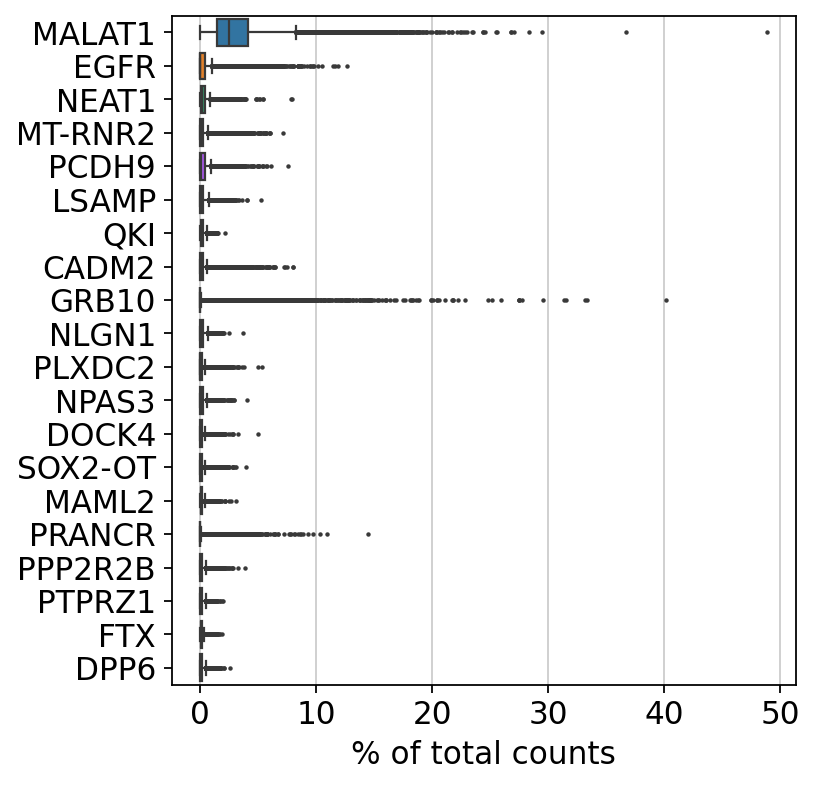

In [19]:
sc.pl.highest_expr_genes(adata, n_top=plot_high_expression_gene_nr, save='highest_gene_expression.svg')

In [20]:
adata.obs['total_counts'][adata.obs['total_counts'] > 300] 

AAACCCAAGAATGTTG-1    1060.0
AAACCCAAGCCACTCG-1    1625.0
AAACCCACATCGAACT-1    1610.0
AAACCCACATCGGTTA-1    1106.0
AAACCCAGTCCTGTTC-1    1865.0
                       ...  
TTTGTTGAGCATTGTC-1    6563.0
TTTGTTGCAGACACAG-1    4789.0
TTTGTTGTCCCTCGAT-1    4272.0
TTTGTTGTCCGATTAG-1    1159.0
TTTGTTGTCTCCGTGT-1    2591.0
Name: total_counts, Length: 45245, dtype: float32

In [21]:
os.getcwd()

'/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell'

In [22]:
## filter for minimum amount of cells and genes per cell
sc.pp.filter_cells(adata, min_genes=filter_min_genes)
print('Cell count after filter for minumum ',filter_min_genes, 'features per cell: ', adata.n_obs)
sc.pp.filter_genes(adata, min_cells=filter_min_cells)
print('Feature count after filter for minumum ',filter_min_cells, 'cells per features: ', adata.n_vars)
sc.pp.filter_cells(adata, min_counts=filter_min_counts_per_cell)
print('Cell count after filter for minumum ',filter_min_counts_per_cell, 'counts per cell: ', adata.n_obs)

logfile.write(str(datetime.now())+' Cell count after filter for minumum '+ str(filter_min_genes) + ' features per cell: ' + str(adata.n_obs)+'\n')
logfile.write(str(datetime.now())+' Feature count after filter for minumum '+ str(filter_min_cells) + ' cells per features: ' + str(adata.n_vars)+'\n')
logfile.flush()

#adata.write('./'+result_file_name+'_filtered_mg_mc.h5ad')

/home/borisvdm/Software/miniconda3/envs/single-cell/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Cell count after filter for minumum  200 features per cell:  45245
filtered out 3269 genes that are detected in less than 3 cells


/home/borisvdm/Software/miniconda3/envs/single-cell/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Feature count after filter for minumum  3 cells per features:  37807
Cell count after filter for minumum  1000 counts per cell:  45245


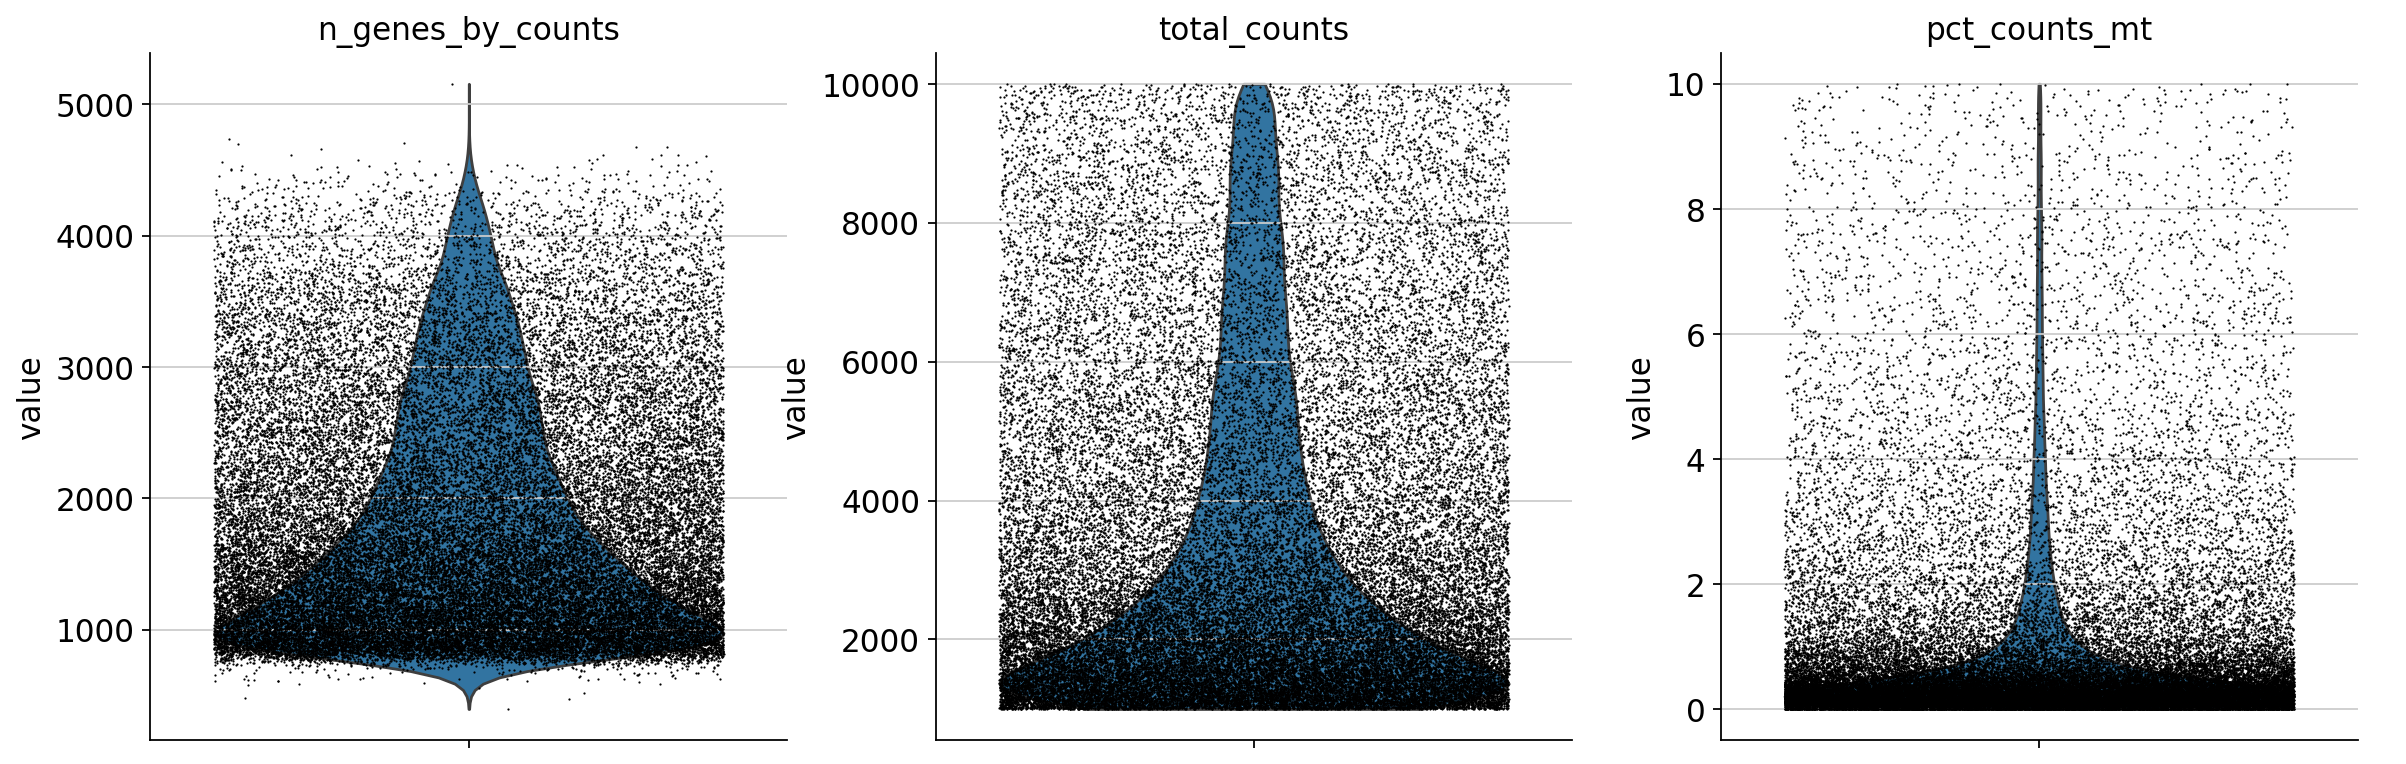

In [23]:
## filter mitochondrial counts
# TODO: make varibale of startswith argument
# annotate the group of mitochondrial genes as 'mt'
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# calculate metrics and store them in the andata format. There are many fine-tune parameters available, I implemented default here
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# visualize some quality metrics in violin plots
# default order is width
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, save='qc_violin_plot.svg')

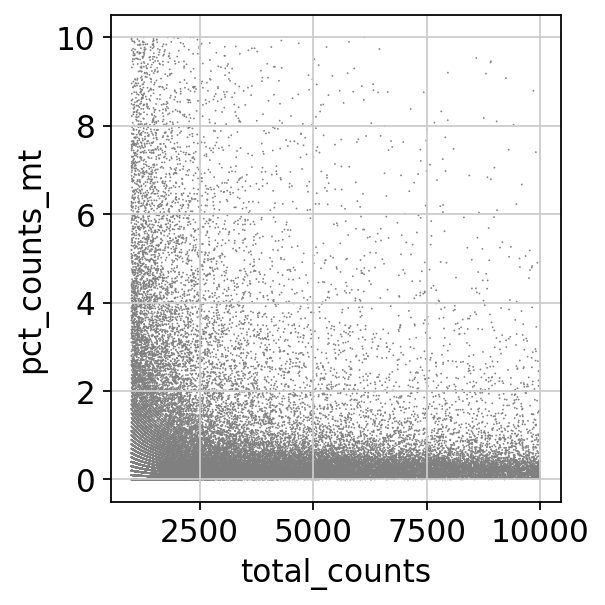

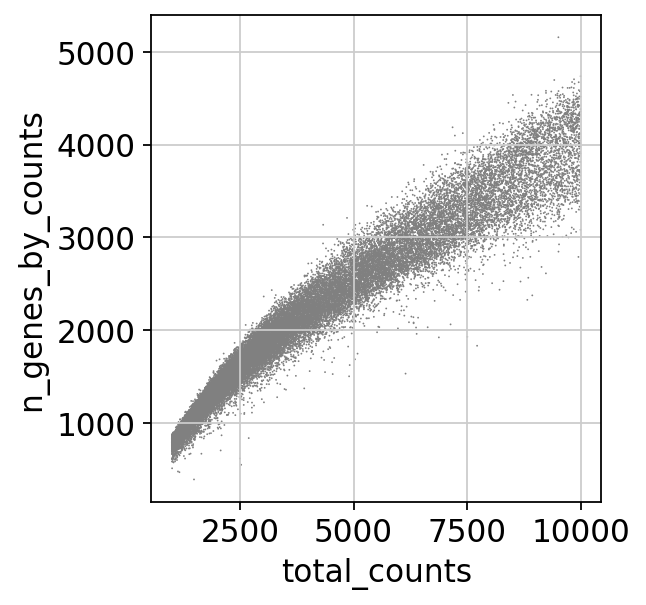

In [24]:
## further visualize mitochondrial counts with scatter plots
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', save='scatter_total_counts_vs_pct_counts_mt.svg')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', save='scatter_total_counts_vs_pct_n_genes_by_counts.svg')

In [25]:
## do the filtering based on that plot or based on default thresholds
adata = adata[adata.obs.n_genes_by_counts < filter_n_genes_by_counts, :]
adata = adata[adata.obs.pct_counts_mt < filter_pct_counts_mt, :]
adata = adata[adata.obs.total_counts < filter_total_counts, :]

print('Cell count after filtering out cells with more than ',filter_n_genes_by_counts, ' expressed genes and more than', filter_pct_counts_mt, '% of mitochondrial counts and total counts < ', str(filter_total_counts)  ,':' , adata.n_obs,)
logfile.write(str(datetime.now())+' Cell count after filter out cells with less than '+ str(filter_n_genes_by_counts) + '  gene count and more than ' + str(filter_pct_counts_mt) + ' % of mitochondrial counts and total counts < '+ str(filter_total_counts)+ ': ' + str(adata.n_obs) +'\n')
logfile.flush()

## save the andata object
adata.write('./'+result_file_name+'_filtered_mg_mc_gc_mt_tc.h5ad')

Cell count after filtering out cells with more than  10000  expressed genes and more than 10 % of mitochondrial counts and total counts <  10000 : 45245
